In [11]:

import json
import os
import os.path as osp
import random
import shutil
import numpy as np
import zipfile
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from tqdm import tqdm

Original Image Size: (224, 224), Unique Pixels: [0, 255]
Resized 2x Size: (112, 112), Unique Pixels: [0, 128, 4, 136, 140, 12, 16, 148, 28, 32, 160, 40, 44, 172, 175, 176, 179, 183, 187, 64, 195, 199, 207, 80, 92, 96, 112, 116, 124]
Resized 4x Size: (56, 56), Unique Pixels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 20, 21, 26, 27, 29, 32, 36, 38, 42, 47, 48, 49, 54, 58, 63, 66, 78, 84, 85, 86, 91, 92, 93, 101, 103, 112, 113, 116, 125, 126]
Resized 8x Size: (28, 28), Unique Pixels: [0, 1, 4, 5, 6, 9, 10, 13, 18, 19, 22, 25, 28, 34, 36, 38, 39, 40, 44, 56, 58, 59]
Resized 16x Size: (14, 14), Unique Pixels: [0, 1, 32, 3, 4, 6, 10, 21, 22, 30]
Resized 32x Size: (7, 7), Unique Pixels: [0, 2, 3, 8, 9]


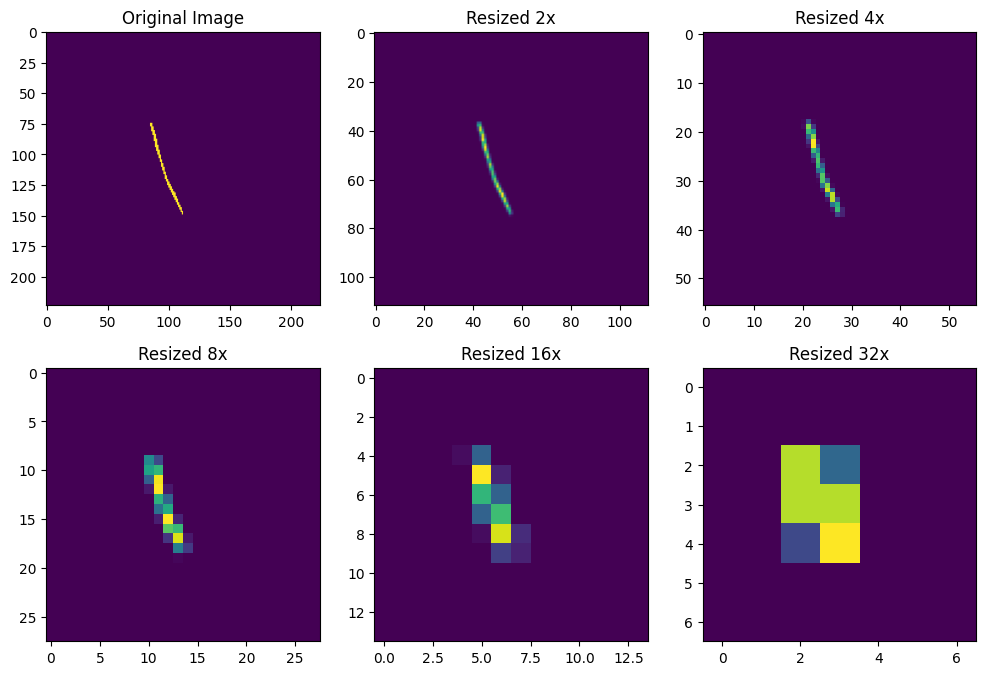

In [18]:
image_path = "data/zhenyu_data/60194/60194-CCD1-负极/顶盖正面_划伤/71ef3aa1-8867-403b-924a-10a7ba65ccd4_000_mask.png"
img = Image.open(image_path).convert('L')
input_size = (224, 224)
input_img = img.resize(input_size, resample=Image.NEAREST)
resized_img_2x = input_img.resize((input_size[0]//2, input_size[1]//2), Image.BILINEAR)
resized_img_4x = input_img.resize((input_size[0]//4, input_size[1]//4), Image.BILINEAR)
resize_img_8x = input_img.resize((input_size[0]//8, input_size[1]//8), Image.BILINEAR)
resize_img_16x = input_img.resize((input_size[0]//16, input_size[1]//16), Image.BILINEAR)
resize_img_32x = input_img.resize((input_size[0]//32, input_size[1]//32), Image.BILINEAR)

unique_pixels = set(input_img.getdata())
print(f"Original Image Size: {input_img.size}, Unique Pixels: {list(unique_pixels)}")
unique_pixels_2x = set(resized_img_2x.getdata())
print(f"Resized 2x Size: {resized_img_2x.size}, Unique Pixels: {list(unique_pixels_2x)}")
unique_pixels_4x = set(resized_img_4x.getdata())
print(f"Resized 4x Size: {resized_img_4x.size}, Unique Pixels: {list(unique_pixels_4x)}")
unique_pixels_8x = set(resize_img_8x.getdata())
print(f"Resized 8x Size: {resize_img_8x.size}, Unique Pixels: {list(unique_pixels_8x)}")
unique_pixels_16x = set(resize_img_16x.getdata())
print(f"Resized 16x Size: {resize_img_16x.size}, Unique Pixels: {list(unique_pixels_16x)}")
unique_pixels_32x = set(resize_img_32x.getdata())
print(f"Resized 32x Size: {resize_img_32x.size}, Unique Pixels: {list(unique_pixels_32x)}")
plt.subplots(2, 3, figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(input_img)
plt.subplot(2, 3, 2)
plt.title("Resized 2x")
plt.imshow(resized_img_2x)
plt.subplot(2, 3, 3)
plt.title("Resized 4x")
plt.imshow(resized_img_4x)
plt.subplot(2, 3, 4)
plt.title("Resized 8x")
plt.imshow(resize_img_8x)
plt.subplot(2, 3, 5)
plt.title("Resized 16x")
plt.imshow(resize_img_16x)
plt.subplot(2, 3, 6)
plt.title("Resized 32x")
plt.imshow(resize_img_32x)
plt.show()

In [30]:
mask

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(1, 224, 224), dtype=uint8)

In [44]:
import os
import os.path as osp
import sys
import torch.nn.functional as F
import torch

sys.path.append("./")

from src.supcon_train.datasets.supcon_dataset import MultiConfigDataset, SupConDataset
from src.utils.config_loader import load_config

config_path = 'configs/supcon_config.yaml'
data_config_path = "configs/data_config_zhenyu.yaml"

supcon_config = load_config(config_path)

dataset = SupConDataset(
        data_config_path=data_config_path,
        split='val',
    )

print(f"数据集样本数: {len(dataset)}")
print(f"类别列表: {dataset.categories}")

数据集样本数: 857
类别列表: ['R角凸起', '划伤-正常', '划伤-重度', '压伤', '字符错位', '开裂', '异物-人造', '异物-杂物、灰尘、黑线', '异物遮蔽', '折痕', '断焊', '无刻码', '氧化', '污渍', '焊洞', '焊渣', '破损', '碰伤', '笔迹', '缺口', '缺胶漏金属', '装配错位-矩形极柱(全局)', '装配错位-矩形极柱(局部)', '金属丝', '间隙大', '飞边']


Original Mask Size: (224, 224), Unique Pixels: [  0 255]
Resized 2x Mask Size: (112, 112), Unique Pixels: [  0  63 127 191 255]
Resized 4x Mask Size: (56, 56), Unique Pixels: [  0  63 127 191 255]
Resized 8x Mask Size: (28, 28), Unique Pixels: [  0  63 127 191 255]
Resized 16x Mask Size: (14, 14), Unique Pixels: [  0  63 127 191 255]
Resized 32x Mask Size: (7, 7), Unique Pixels: [ 0 63]


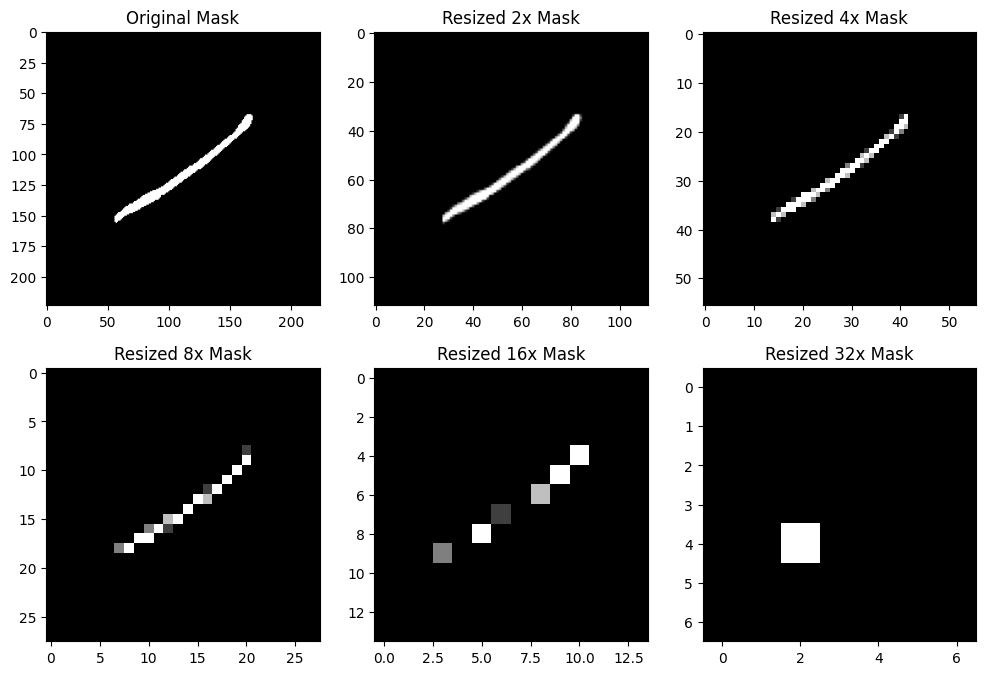

In [55]:
data_item = dataset[4]
view1_image = data_item['view1_image']
view1_mask = data_item['view1_mask']


mask = view1_mask.unsqueeze(0)
H, W = mask.shape[-2], mask.shape[-1]
mask_resized_2x = F.interpolate(mask, size=(H//2, W//2), mode='bilinear', align_corners=False)
mask_resized_4x = F.interpolate(mask, size=(H//4, W//4), mode='bilinear', align_corners=False)
mask_resized_8x = F.interpolate(mask, size=(H//8, W//8), mode='bilinear', align_corners=False)
mask_resized_16x = F.interpolate(mask, size=(H//16, W//16), mode='bilinear', align_corners=False)
mask_resized_32x = F.interpolate(mask, size=(H//32, W//32), mode='bilinear', align_corners=False)

mask = (mask.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)
mask_2x = (mask_resized_2x.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)
mask_4x = (mask_resized_4x.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)
mask_8x = (mask_resized_8x.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)
mask_16x = (mask_resized_16x.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)
mask_32x = (mask_resized_32x.squeeze(0).squeeze(0).numpy() * 255).astype(np.uint8)

print(f"Original Mask Size: {mask.shape}, Unique Pixels: {np.unique(mask)}")
print(f"Resized 2x Mask Size: {mask_2x.shape}, Unique Pixels: {np.unique(mask_2x)}")
print(f"Resized 4x Mask Size: {mask_4x.shape}, Unique Pixels: {np.unique(mask_4x)}")
print(f"Resized 8x Mask Size: {mask_8x.shape}, Unique Pixels: {np.unique(mask_8x)}")
print(f"Resized 16x Mask Size: {mask_16x.shape}, Unique Pixels: {np.unique(mask_16x)}")
print(f"Resized 32x Mask Size: {mask_32x.shape}, Unique Pixels: {np.unique(mask_32x)}")

plt.subplots(2, 3, figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.title("Original Mask")
plt.imshow(mask, cmap='gray')
plt.subplot(2, 3, 2)
plt.title("Resized 2x Mask")
plt.imshow(mask_2x, cmap='gray')
plt.subplot(2, 3, 3)
plt.title("Resized 4x Mask")
plt.imshow(mask_4x, cmap='gray')
plt.subplot(2, 3, 4)
plt.title("Resized 8x Mask")
plt.imshow(mask_8x, cmap='gray')
plt.subplot(2, 3, 5)
plt.title("Resized 16x Mask")
plt.imshow(mask_16x, cmap='gray')
plt.subplot(2, 3, 6)
plt.title("Resized 32x Mask")
plt.imshow(mask_32x, cmap='gray')
plt.show()